<h1 style='text-align: center; font-family: Colonna MT; font-size: 35px; font-weight: 600'>Descriptives Statistics Preliminary EDA</h1>

----

<h1 style='font-family: Bradley Hand ITC; font-weight: 600; font-size: 25px; text-align: left'>1.0. IMPORT REQUIRED LIBRARIES</h1>

In [1]:
if __name__ == "__main__":
    from scipy.stats import skew, kurtosis
    from sklearn.impute import SimpleImputer
    from scipy.stats import pearsonr
    import scipy.stats as stats  
    
    from typing import List, Optional
    from pypalettes import load_cmap
    import matplotlib.pyplot as plt
    import matplotlib as mpl
    import networkx as nx
    import seaborn as sns
    
    import pandas as pd
    import numpy as np
    import random
    import warnings 

    from src.info import info, summary

    cmap = load_cmap("enara", cmap_type="continuous", reverse=True)
    pd.set_option('display.float_format', lambda x: '%.2f' % x)
    pd.set_option('display.max_columns', 100)
    warnings.simplefilter("ignore") 

    #plt.style.use("dark_background")
    mpl.rcParams.update({
        #"figure.figsize": (10, 6),
        #"axes.facecolor": "#0d1117",
        #"figure.facecolor": "#0d1117",
        #"axes.edgecolor": "#2a2e39",
        #"axes.labelcolor": "#e6edf3",
        #"xtick.color": "#9da5b4",
        #"ytick.color": "#9da5b4",
        #"grid.color": "#2a2e39",
        #"text.color": "white",
        #"font.family": "Dubai",
        #"font.size": 11
      })

<h1 style='font-family: Bradley Hand ITC; font-weight: 600; font-size: 25px; text-align: left'>2.0. IMPORTING AND PREPARE DATASETS </h1>

In [2]:
if __name__ == "__main__":
    FILEPATH = "./Datasets/Soil Health Dataset.csv"
    df = pd.read_csv(FILEPATH)
    display(df.sample(5))

,Soil Texture,Soil pH,Organic Carbon (%),Total Nitrogen (%),Available Phosphorus (ppm),Exchangeable Potassium (cmol/kg),Cation Exchange Capacity (cmol/kg),Soil Moisture (%),Bulk Density (g/cm³),Electrical Conductivity (dS/m),Soil Respiration CO₂ (mg/kg/day)
231,Silty Clay,5.83,1.58,0.11,11.85,0.51,32.06,24.69,1.40,0.26,31.65
205,Silty Clay,6.76,2.49,0.16,17.22,0.49,9.84,31.35,1.56,0.43,48.14
251,Silty Clay,5.91,0.81,0.18,10.05,0.73,37.18,26.25,1.49,1.55,63.33
98,Sandy Loam,6.50,1.23,0.12,4.11,0.23,4.47,15.01,1.48,0.55,14.96
227,Silty Clay,6.14,0.93,0.11,1.59,0.37,35.71,18.87,1.43,0.32,11.36


<h1 style='font-family: Bradley Hand ITC; font-size: 25px; font-weight: 600'> 3.0: DATA OVERVIEW AND QUALITY CHECKS</h1>

<h3 style='font-family: Bradley Hand ITC; font-size: 18px; font-weight: 600'> 3.1: DATA SHAPE AND COLUMNS</h3>

In [3]:
df.shape

(400, 11)

In [4]:
for col in df.columns: print(f"{"":<3}--  {col}")

   --  Soil Texture
   --  Soil pH
   --  Organic Carbon (%)
   --  Total Nitrogen (%)
   --  Available Phosphorus (ppm)
   --  Exchangeable Potassium (cmol/kg)
   --  Cation Exchange Capacity (cmol/kg)
   --  Soil Moisture (%)
   --  Bulk Density (g/cm³)
   --  Electrical Conductivity (dS/m)
   --  Soil Respiration CO₂ (mg/kg/day)


In [5]:
info(df)

----------------------------------------------------------------------------
| Index | Column Name               | Dtype   | Non-Null | Nulls | Entries |
----------------------------------------------------------------------------
| 0     | Soil Texture              | object  | 400      | 0     | 400     |
| 1     | Soil pH                   | float64 | 400      | 0     | 400     |
| 2     | Organic Carbon (%)        | float64 | 400      | 0     | 400     |
| 3     | Total Nitrogen (%)        | float64 | 400      | 0     | 400     |
| 4     | Available Phosphorus (... | float64 | 400      | 0     | 400     |
| 5     | Exchangeable Potassium... | float64 | 400      | 0     | 400     |
| 6     | Cation Exchange Capaci... | float64 | 400      | 0     | 400     |
| 7     | Soil Moisture (%)         | float64 | 400      | 0     | 400     |
| 8     | Bulk Density (g/cm³)      | float64 | 400      | 0     | 400     |
| 9     | Electrical Conductivit... | float64 | 400      | 0     | 400     |

<h3 style='font-family: Bradley Hand ITC; font-size: 18px; font-weight: 600'> 3.2: COLUMNS SUMMARIES</h3>

In [7]:
summary(df)

,col_name,col_dtype,num_of_nulls,num_of_non_nulls,num_of_distinct_values,distinct_values_counts
0,Soil Texture,object,0,400,4,"{'Sandy Loam': 100, 'Clay Loam': 100, 'Silty C..."
1,Soil pH,float64,0,400,400,"{4.588581469316734: 1, 4.971601883490142: 1, 5..."
2,Organic Carbon (%),float64,0,400,400,"{4.919684440237253: 1, 4.22859839087855: 1, 4...."
3,Total Nitrogen (%),float64,0,400,400,"{0.2842880609168573: 1, 0.2960359023329535: 1,..."
4,Available Phosphorus (ppm),float64,0,400,400,"{2.3581247361722246: 1, 15.75541746230509: 1, ..."
5,Exchangeable Potassium (cmol/kg),float64,0,400,400,"{0.5232871307740251: 1, 0.4762264922961615: 1,..."
6,Cation Exchange Capacity (cmol/kg),float64,0,400,400,"{19.58776723609973: 1, 20.90363822201643: 1, 2..."
7,Soil Moisture (%),float64,0,400,400,"{61.38395639689789: 1, 55.6760411655429: 1, 56..."
8,Bulk Density (g/cm³),float64,0,400,400,"{0.923855495377374: 1, 0.8551457163472139: 1, ..."
9,Electrical Conductivity (dS/m),float64,0,400,400,"{0.2120236722247101: 1, 0.09440950729242: 1, 0..."


<h3 style='font-family: Bradley Hand ITC; font-size: 18px; font-weight: 600'> 3.3: HANDLING MISSING VALUES IF ANY IN DATASET</h3>

In [72]:
def simple_imputation(df, variables: List[str], categories: List[str]):
    cat_imputer = SimpleImputer(strategy='most_frequent')
    num_imputer = SimpleImputer(strategy='median')
        
    df[categories] = cat_imputer.fit_transform(df[categories])
    df[variables] = num_imputer.fit_transform(df[variables])
    
    return df

if __name__ == "__main__":
    variables = ['Soil pH', 'Organic Carbon (%)', 'Total Nitrogen (%)',
       'Available Phosphorus (ppm)', 'Exchangeable Potassium (cmol/kg)',
       'Cation Exchange Capacity (cmol/kg)', 'Soil Moisture (%)',
       'Bulk Density (g/cm³)', 'Electrical Conductivity (dS/m)',
       'Soil Respiration CO₂ (mg/kg/day)']
    
    df = simple_imputation(df, variables, categories = ['Soil Texture'])
    results = column_summaries(df)
    display(results)

,col_name,col_dtype,num_of_nulls,num_of_non_nulls,num_of_distinct_values,distinct_values_counts
0,Soil Texture,object,0,400,4,"{'Sandy Loam': 100, 'Clay Loam': 100, 'Silty C..."
1,Soil pH,float64,0,400,400,"{4.588581469316734: 1, 4.971601883490142: 1, 5..."
2,Organic Carbon (%),float64,0,400,400,"{4.919684440237253: 1, 4.22859839087855: 1, 4...."
3,Total Nitrogen (%),float64,0,400,400,"{0.2842880609168573: 1, 0.2960359023329535: 1,..."
4,Available Phosphorus (ppm),float64,0,400,400,"{2.3581247361722246: 1, 15.75541746230509: 1, ..."
5,Exchangeable Potassium (cmol/kg),float64,0,400,400,"{0.5232871307740251: 1, 0.4762264922961615: 1,..."
6,Cation Exchange Capacity (cmol/kg),float64,0,400,400,"{19.58776723609973: 1, 20.90363822201643: 1, 2..."
7,Soil Moisture (%),float64,0,400,400,"{61.38395639689789: 1, 55.6760411655429: 1, 56..."
8,Bulk Density (g/cm³),float64,0,400,400,"{0.923855495377374: 1, 0.8551457163472139: 1, ..."
9,Electrical Conductivity (dS/m),float64,0,400,400,"{0.2120236722247101: 1, 0.09440950729242: 1, 0..."


<h3 style='font-family: Bradley Hand ITC; font-size: 18px; font-weight: 600'> 3.4: EXPLORING INVALID DTYPES ENTRIES</h3>

In [73]:
def simplify_dtype(dtype):
    if dtype in (int, float, np.number): 
        return 'Numeric'
    elif np.issubdtype(dtype, np.datetime64): 
        return 'Datetime'
    elif dtype == str: 
        return 'String'
    elif dtype == type(None): 
        return 'Missing'
    else: 
        return 'Other'

def analyze_column_dtypes(df):
    all_dtypes = {'Numeric', 'Datetime', 'String', 'Missing', 'Other'}
    results = pd.DataFrame(index=df.columns, columns=list(all_dtypes), dtype=object).fillna('-')
    
    for column in df.columns:
        dtypes = df[column].apply(lambda x: simplify_dtype(type(x))).value_counts()
        percentages = (dtypes / len(df)) * 100
        for dtype, percent in percentages.items():
            if percent > 0:
                results.at[column, dtype] = f'{percent:.2f}%'
            else:
                results.at[column, dtype] = '-'
    return results

if __name__ == "__main__":
    results = analyze_column_dtypes(df)
    display(results)

,String,Missing,Numeric,Datetime,Other
Soil Texture,100.00%,-,-,-,-
Soil pH,-,-,100.00%,-,-
Organic Carbon (%),-,-,100.00%,-,-
Total Nitrogen (%),-,-,100.00%,-,-
Available Phosphorus (ppm),-,-,100.00%,-,-
Exchangeable Potassium (cmol/kg),-,-,100.00%,-,-
Cation Exchange Capacity (cmol/kg),-,-,100.00%,-,-
Soil Moisture (%),-,-,100.00%,-,-
Bulk Density (g/cm³),-,-,100.00%,-,-
Electrical Conductivity (dS/m),-,-,100.00%,-,-


<H3 style='font-family: Bradley Hand ITC; font-size: 18px;  font-weight: 600''>3.5: OUTLIERS DETECTION AND HANDLING USING IQR</H3>

In [74]:
def get_outlier_counts(df: pd.DataFrame, variables: Optional[List[str]] = None, group: Optional[str] = None) -> pd.DataFrame:
    if variables is None:
        variables = df.select_dtypes(include='number').columns.tolist()
        if group in variables:
            variables.remove(group)

    results = []
    grouped = df.groupby(group) if group else [(None, df)]
    
    for group_name, group_df in grouped:
        for col in variables:
            Q1 = group_df[col].quantile(0.25)
            Q3 = group_df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            
            outlier_count = group_df[(group_df[col] < lower) | (group_df[col] > upper)].shape[0]
            
            row = {
                f'{group}': group_name,
                'Variable': col,
                'Counts': outlier_count,
                'Total Observations': len(group_df),
                'Proportion (%)': round((outlier_count / len(group_df)) * 100, 2),
            }
            if group:
                row[group] = group_name
            results.append(row)
    
    results = pd.DataFrame(results)
    results = results.drop(columns=[f'{group}']) if group is None else results
    return results

if __name__ == "__main__":
    results = get_outlier_counts(df)
    display(results)

,Variable,Counts,Total Observations,Proportion (%)
0,Soil pH,2,400,0.50
1,Organic Carbon (%),0,400,0.00
2,Total Nitrogen (%),0,400,0.00
3,Available Phosphorus (ppm),6,400,1.50
4,Exchangeable Potassium (cmol/kg),2,400,0.50
5,Cation Exchange Capacity (cmol/kg),4,400,1.00
6,Soil Moisture (%),1,400,0.25
7,Bulk Density (g/cm³),0,400,0.00
8,Electrical Conductivity (dS/m),12,400,3.00
9,Soil Respiration CO₂ (mg/kg/day),10,400,2.50


In [75]:
def get_outliers(df: pd.DataFrame, group: str, variables: Optional[List[str]] = None):
    variables = variables if variables else df.select_dtypes(include='number').columns.tolist()[1:]
    outlier_summary = pd.DataFrame(index=variables)

    grouped = df.groupby(group)
    for group_name, group_data in grouped:
        outlier_counts = []
        for col in variables:
            Q1 = group_data[col].quantile(0.25)
            Q3 = group_data[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            count = group_data[(group_data[col] < lower) | (group_data[col] > upper)].shape[0]
            outlier_counts.append(count)
        outlier_summary[group_name] = outlier_counts

    total_row = df.groupby(group).size()
    outlier_summary.loc["Total Observations"] = total_row

    return outlier_summary.fillna(0).astype(int)

if __name__ == "__main__":
    outliers_table = get_outliers(df, group='Soil Texture')
    display(outliers_table)

,Clay Loam,Peat Soil,Sandy Loam,Silty Clay
Organic Carbon (%),0,2,1,2
Total Nitrogen (%),3,0,2,2
Available Phosphorus (ppm),1,1,8,3
Exchangeable Potassium (cmol/kg),0,0,2,0
Cation Exchange Capacity (cmol/kg),2,2,4,1
Soil Moisture (%),0,1,2,3
Bulk Density (g/cm³),2,1,0,0
Electrical Conductivity (dS/m),1,6,2,4
Soil Respiration CO₂ (mg/kg/day),4,3,2,1
Total Observations,100,100,100,100


<h1 style='font-family: Bradley Hand ITC; font-size: 25px;  font-weight: 600''>4.0: DATASETS STATISTICS DESCRIPTIONS</h1>

<h4 style='font-family: Bradley Hand ITC; font-size: 20px;  font-weight: 600''>4.1: OVERALL STATISTIC DESCRIPTIONS</h4>

In [76]:
results = df.describe().transpose()
display(results)

,count,mean,std,min,25%,50%,75%,max
Soil pH,400.00,6.10,0.85,3.95,5.62,6.40,6.69,7.45
Organic Carbon (%),400.00,2.52,1.55,0.24,1.40,1.93,3.47,6.17
Total Nitrogen (%),400.00,0.17,0.08,0.00,0.11,0.14,0.22,0.37
Available Phosphorus (ppm),400.00,11.67,7.31,0.40,6.10,10.45,15.90,43.15
Exchangeable Potassium (cmol/kg),400.00,0.52,0.11,0.18,0.44,0.52,0.60,0.79
Cation Exchange Capacity (cmol/kg),400.00,18.90,11.47,0.51,10.07,17.51,26.37,59.23
Soil Moisture (%),400.00,32.90,14.67,4.56,22.11,29.22,42.67,77.04
Bulk Density (g/cm³),400.00,1.28,0.25,0.64,1.13,1.34,1.47,1.75
Electrical Conductivity (dS/m),400.00,0.30,0.22,0.00,0.15,0.26,0.41,1.55
Soil Respiration CO₂ (mg/kg/day),400.00,48.17,30.59,2.86,26.47,42.04,63.82,206.51


In [77]:
results = df.describe(include='all').transpose()
display(results.fillna("-"))

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Soil Texture,400.00,4,Sandy Loam,100,-,-,-,-,-,-,-
Soil pH,400.00,-,-,-,6.10,0.85,3.95,5.62,6.40,6.69,7.45
Organic Carbon (%),400.00,-,-,-,2.52,1.55,0.24,1.40,1.93,3.47,6.17
Total Nitrogen (%),400.00,-,-,-,0.17,0.08,0.00,0.11,0.14,0.22,0.37
Available Phosphorus (ppm),400.00,-,-,-,11.67,7.31,0.40,6.10,10.45,15.90,43.15
Exchangeable Potassium (cmol/kg),400.00,-,-,-,0.52,0.11,0.18,0.44,0.52,0.60,0.79
Cation Exchange Capacity (cmol/kg),400.00,-,-,-,18.90,11.47,0.51,10.07,17.51,26.37,59.23
Soil Moisture (%),400.00,-,-,-,32.90,14.67,4.56,22.11,29.22,42.67,77.04
Bulk Density (g/cm³),400.00,-,-,-,1.28,0.25,0.64,1.13,1.34,1.47,1.75
Electrical Conductivity (dS/m),400.00,-,-,-,0.30,0.22,0.00,0.15,0.26,0.41,1.55


<h4 style='font-family: Bradley Hand ITC; font-size: 20px;  font-weight: 600'>4.2: CONTINUOUS VARIABLES STATISTIC DESCRIPTIONS</h4>

In [78]:
def summary_statistics(df: pd.DataFrame, variables: Optional[List[str]] = None, group: Optional[str] = None) -> pd.DataFrame:
    grouped_data = df.groupby(group) if group else [(None, df)]
    if variables is None: variables = df.select_dtypes(include=[np.number]).columns
    
    results = []

    for col in variables:
        for grp_name, grp_df in grouped_data:
            counts = grp_df[col].count()
            mean_val = grp_df[col].mean()
            median_val = grp_df[col].median()
            mode_val = grp_df[col].mode().iloc[0] if not grp_df[col].mode().empty else np.nan
            std_dev = grp_df[col].std()
            variance = grp_df[col].var()
            value_range = grp_df[col].max() - grp_df[col].min()
            iqr = grp_df[col].quantile(0.75) - grp_df[col].quantile(0.25)
            skewness_val = skew(grp_df[col], nan_policy='omit')
            kurtosis_val = kurtosis(grp_df[col], nan_policy='omit')
            
            sem = stats.sem(grp_df[col], nan_policy='omit')
            ci_low, ci_up = stats.t.interval(0.95, counts - 1, loc=mean_val, scale=sem) if counts > 1 else (np.nan, np.nan)

            results.append({
                'Variable': col,
                group if group else 'None': grp_name,
                #'η': counts,
                'Mean': mean_val,
                'Median': median_val,
                'Mode': mode_val,
                'Std Deviation': std_dev,
                'Variance': variance,
                'Range': value_range,
                'IQR': iqr,
                'Skewness': skewness_val,
                'Kurtosis': kurtosis_val,
                '95% CI Lower': ci_low,
                '95% CI Upper': ci_up
            })
    
    results = pd.DataFrame(results)
    results = results.drop(columns=['None']) if group is None else results
    return results

if __name__ == "__main__":
    variables = ['Soil pH', 'Organic Carbon (%)', 'Total Nitrogen (%)',
           'Available Phosphorus (ppm)', 'Exchangeable Potassium (cmol/kg)',
           'Cation Exchange Capacity (cmol/kg)', 'Soil Moisture (%)',
           'Bulk Density (g/cm³)', 'Electrical Conductivity (dS/m)',
           'Soil Respiration CO₂ (mg/kg/day)'
            ]
    results = summary_statistics(df, variables)
    display(results)

,Variable,Mean,Median,Mode,Std Deviation,Variance,Range,IQR,Skewness,Kurtosis,95% CI Lower,95% CI Upper
0,Soil pH,6.10,6.40,3.95,0.85,0.72,3.50,1.07,-0.84,-0.55,6.01,6.18
1,Organic Carbon (%),2.52,1.93,0.24,1.55,2.41,5.93,2.07,0.83,-0.71,2.37,2.68
2,Total Nitrogen (%),0.17,0.14,0.00,0.08,0.01,0.36,0.11,0.79,-0.54,0.16,0.18
3,Available Phosphorus (ppm),11.67,10.45,0.40,7.31,53.38,42.75,9.80,0.87,0.68,10.95,12.39
4,Exchangeable Potassium (cmol/kg),0.52,0.52,0.18,0.11,0.01,0.61,0.16,-0.12,-0.20,0.51,0.53
5,Cation Exchange Capacity (cmol/kg),18.90,17.51,0.51,11.47,131.51,58.72,16.30,0.67,0.13,17.77,20.02
6,Soil Moisture (%),32.90,29.22,4.56,14.67,215.17,72.48,20.56,0.57,-0.54,31.46,34.34
7,Bulk Density (g/cm³),1.28,1.34,0.64,0.25,0.06,1.12,0.34,-0.57,-0.69,1.26,1.30
8,Electrical Conductivity (dS/m),0.30,0.26,0.00,0.22,0.05,1.55,0.27,1.35,3.02,0.28,0.33
9,Soil Respiration CO₂ (mg/kg/day),48.17,42.04,2.86,30.59,935.71,203.65,37.35,1.31,2.77,45.17,51.18


<h4 style='font-family: Bradley Hand ITC; font-size: 20px;  font-weight: 600'>4.3: CONTINUOUS VARIABLES GROUPED STATISTICS</h4>

In [79]:
if __name__ == "__main__":
    variables = ['Soil pH', 'Organic Carbon (%)', 'Total Nitrogen (%)',
           'Available Phosphorus (ppm)', 'Exchangeable Potassium (cmol/kg)',
           'Cation Exchange Capacity (cmol/kg)', 'Soil Moisture (%)',
           'Bulk Density (g/cm³)', 'Electrical Conductivity (dS/m)',
           'Soil Respiration CO₂ (mg/kg/day)'
            ]
    results = summary_statistics(df, variables, group='Soil Texture')
    display(results)

,Variable,Soil Texture,Mean,Median,Mode,Std Deviation,Variance,Range,IQR,Skewness,Kurtosis,95% CI Lower,95% CI Upper
0,Soil pH,Clay Loam,6.81,6.82,6.02,0.31,0.09,1.43,0.40,-0.14,-0.28,6.75,6.88
1,Soil pH,Peat Soil,4.75,4.77,3.95,0.31,0.10,1.70,0.38,-0.07,0.21,4.69,4.82
2,Soil pH,Sandy Loam,6.47,6.46,5.71,0.27,0.07,1.34,0.30,-0.18,-0.16,6.41,6.52
3,Soil pH,Silty Clay,6.34,6.40,5.54,0.29,0.09,1.36,0.41,-0.31,-0.35,6.29,6.40
4,Organic Carbon (%),Clay Loam,2.20,2.20,1.12,0.50,0.25,2.28,0.67,0.11,-0.41,2.09,2.30
5,Organic Carbon (%),Peat Soil,5.01,4.96,3.68,0.45,0.21,2.49,0.51,0.06,0.13,4.92,5.10
6,Organic Carbon (%),Sandy Loam,1.21,1.24,0.24,0.48,0.23,2.32,0.67,0.38,-0.03,1.12,1.31
7,Organic Carbon (%),Silty Clay,1.68,1.62,0.74,0.47,0.22,2.31,0.55,0.50,0.12,1.59,1.77
8,Total Nitrogen (%),Clay Loam,0.15,0.15,0.06,0.03,0.00,0.18,0.04,-0.02,0.57,0.14,0.15
9,Total Nitrogen (%),Peat Soil,0.29,0.30,0.21,0.03,0.00,0.16,0.04,-0.28,-0.26,0.29,0.30


<h4 style='font-family: Bradley Hand ITC; font-size: 20px;  font-weight: 600'>4.4: CONTINUOUS VARIABLES GROUPED STATISTICS | MEAN COMPARISONS</h4>

In [80]:
def grouped_statistics(df: pd.DataFrame, variables: List[str], group: str) -> pd.DataFrame:
    variables = variables.remove(group) if group in variables else variables
        
    ungrouped = df.drop(columns=[group])
    grand_mean = ungrouped[variables].mean()
    sem = ungrouped[variables].sem()
    cv = ungrouped[variables].std() / ungrouped[variables].mean() * 100
    grouped = df.groupby(group)[variables].agg(['mean', 'sem']).reset_index()
    
    results = pd.DataFrame()
    for variable in variables:
        results[variable] = grouped.apply(
            lambda x: f"{x[(variable, 'mean')]:.2f} ± {x[(variable, 'sem')]:.2f}", axis=1
        )
    
    results.insert(0, group, grouped[group])
    grand_mean_row = ['Grand Mean'] + grand_mean.tolist()
    sem_row = ['SEM'] + sem.tolist()
    cv_row = ['%CV'] + cv.tolist()
    
    results.loc[len(results)] = grand_mean_row
    results.loc[len(results)] = sem_row
    results.loc[len(results)] = cv_row
    
    return results

if __name__ == "__main__":
    variables = ['Soil pH', 'Organic Carbon (%)', 'Total Nitrogen (%)',
           'Available Phosphorus (ppm)', 'Exchangeable Potassium (cmol/kg)',
           'Cation Exchange Capacity (cmol/kg)', 'Soil Moisture (%)',
           'Bulk Density (g/cm³)', 'Electrical Conductivity (dS/m)',
           'Soil Respiration CO₂ (mg/kg/day)'
            ]
    results = grouped_statistics(df, variables, group='Soil Texture')
    display(results.transpose())

,0,1,2,3,4,5,6
Soil Texture,Clay Loam,Peat Soil,Sandy Loam,Silty Clay,Grand Mean,SEM,%CV
Soil pH,6.81 ± 0.03,4.75 ± 0.03,6.47 ± 0.03,6.34 ± 0.03,6.10,0.04,13.91
Organic Carbon (%),2.20 ± 0.05,5.01 ± 0.05,1.21 ± 0.05,1.68 ± 0.05,2.52,0.08,61.52
Total Nitrogen (%),0.15 ± 0.00,0.29 ± 0.00,0.10 ± 0.00,0.13 ± 0.00,0.17,0.00,48.47
Available Phosphorus (ppm),16.38 ± 0.81,11.92 ± 0.66,8.41 ± 0.60,9.96 ± 0.58,11.67,0.37,62.62
Exchangeable Potassium (cmol/kg),0.60 ± 0.01,0.50 ± 0.01,0.45 ± 0.01,0.54 ± 0.01,0.52,0.01,21.69
Cation Exchange Capacity (cmol/kg),25.02 ± 1.01,21.12 ± 1.04,9.59 ± 0.80,19.86 ± 1.11,18.90,0.57,60.68
Soil Moisture (%),29.01 ± 0.83,53.65 ± 0.78,21.14 ± 0.75,27.80 ± 0.81,32.90,0.73,44.59
Bulk Density (g/cm³),1.29 ± 0.01,0.90 ± 0.01,1.52 ± 0.01,1.41 ± 0.01,1.28,0.01,19.85
Electrical Conductivity (dS/m),0.39 ± 0.02,0.28 ± 0.02,0.22 ± 0.02,0.33 ± 0.02,0.30,0.01,71.34


<h1 style='font-family: Bradley Hand ITC; font-size: 25px; font-weight: 600'>5.0:   CORRELATION ANALYSIS | RELATIONSHIP BETWEEN VARIABLES</h1>

<h3 style='font-family: Bradley Hand ITC; font-size: 20px; font-weight: 600'>5.1: CORRELATION COEFFICIENTS </h3>

In [8]:
def compute_correlation_matrix(df, method="pearson", visualize=True):
    if method not in ['pearson', 'spearman', 'kendall']: 
        error = "Invalid method. Choose from 'pearson', 'spearman', or 'kendall'."
        raise ValueError(error)
        
    numeric_df = df.select_dtypes(include=['number'])
    corr_matrix = numeric_df.corr(method=method)
    
    return corr_matrix

if __name__ == "__main__":
    variables = ['Soil pH', 'Organic Carbon (%)', 'Total Nitrogen (%)',
           'Available Phosphorus (ppm)', 'Exchangeable Potassium (cmol/kg)',
           'Cation Exchange Capacity (cmol/kg)', 'Soil Moisture (%)',
           'Bulk Density (g/cm³)', 'Electrical Conductivity (dS/m)',
           'Soil Respiration CO₂ (mg/kg/day)'
            ]
    correlation_matrix = compute_correlation_matrix(df[variables], method="pearson")
    display(correlation_matrix)

,Soil pH,Organic Carbon (%),Total Nitrogen (%),Available Phosphorus (ppm),Exchangeable Potassium (cmol/kg),Cation Exchange Capacity (cmol/kg),Soil Moisture (%),Bulk Density (g/cm³),Electrical Conductivity (dS/m),Soil Respiration CO₂ (mg/kg/day)
Soil pH,1.00,-0.82,-0.80,0.05,0.15,-0.06,-0.71,0.74,0.07,-0.25
Organic Carbon (%),-0.82,1.00,0.87,0.14,0.01,0.20,0.80,-0.87,-0.02,0.38
Total Nitrogen (%),-0.80,0.87,1.00,0.12,0.01,0.20,0.76,-0.83,-0.02,0.37
Available Phosphorus (ppm),0.05,0.14,0.12,1.00,0.15,0.24,0.07,-0.17,0.04,0.15
Exchangeable Potassium (cmol/kg),0.15,0.01,0.01,0.15,1.00,0.26,-0.03,-0.05,0.09,0.09
Cation Exchange Capacity (cmol/kg),-0.06,0.20,0.20,0.24,0.26,1.00,0.18,-0.28,0.14,0.22
Soil Moisture (%),-0.71,0.80,0.76,0.07,-0.03,0.18,1.00,-0.76,0.02,0.35
Bulk Density (g/cm³),0.74,-0.87,-0.83,-0.17,-0.05,-0.28,-0.76,1.00,-0.04,-0.37
Electrical Conductivity (dS/m),0.07,-0.02,-0.02,0.04,0.09,0.14,0.02,-0.04,1.00,0.04
Soil Respiration CO₂ (mg/kg/day),-0.25,0.38,0.37,0.15,0.09,0.22,0.35,-0.37,0.04,1.00


<h3 style='font-family: Bradley Hand ITC; font-size: 20px; font-weight: 600'>5.2: CORRELATION COEFFICIENTS NETWORK </h3>

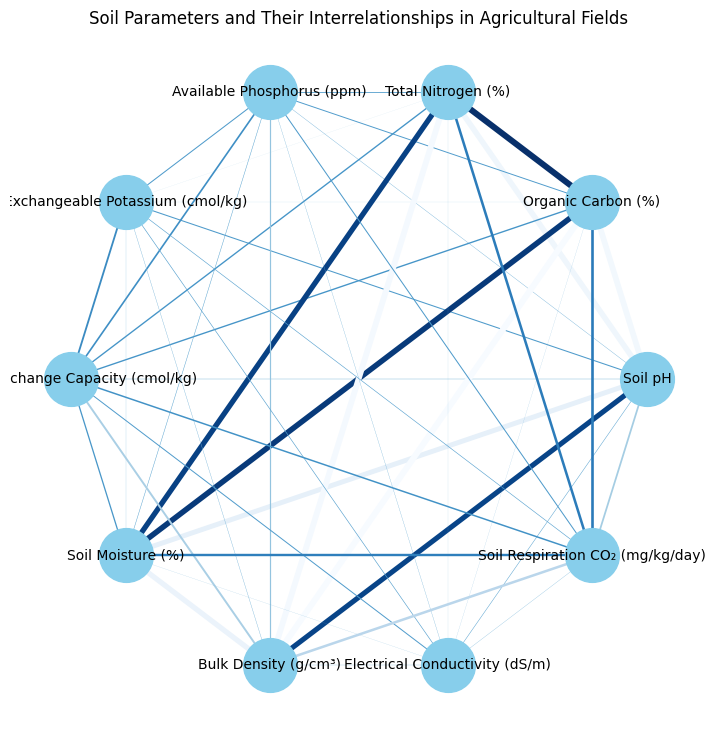

In [9]:
if __name__ == "__main__":
    G = nx.Graph()
    for variable in correlation_matrix.columns:
        G.add_node(variable)
    
    for i, variable1 in enumerate(correlation_matrix.columns):
        for j, variable2 in enumerate(correlation_matrix.columns):
            if i < j:  
                weight = correlation_matrix.loc[variable1, variable2]
                G.add_edge(variable1, variable2, weight=weight)

    fig, ax = plt.subplots(figsize=(9,9))
    
    pos = nx.circular_layout(G)
    edges = G.edges(data=True)
    weights = [d['weight']*5 for (u,v,d) in edges]
    
    nx.draw(
        G, 
        pos, 
        with_labels=True, 
        node_size=1500, 
        node_color='skyblue', 
        width=weights, 
        edge_color=weights, 
        edge_cmap=plt.cm.Blues,
        font_size=10
        )
    
    plt.title("Soil Parameters and Their Interrelationships in Agricultural Fields", color='k', weight=500)
    plt.show()

<h3 style='font-family: Bradley Hand ITC; font-size: 20px; font-weight: 600'>5.3: CORRELATION COEFFICIENTS HEATMAP </h3>

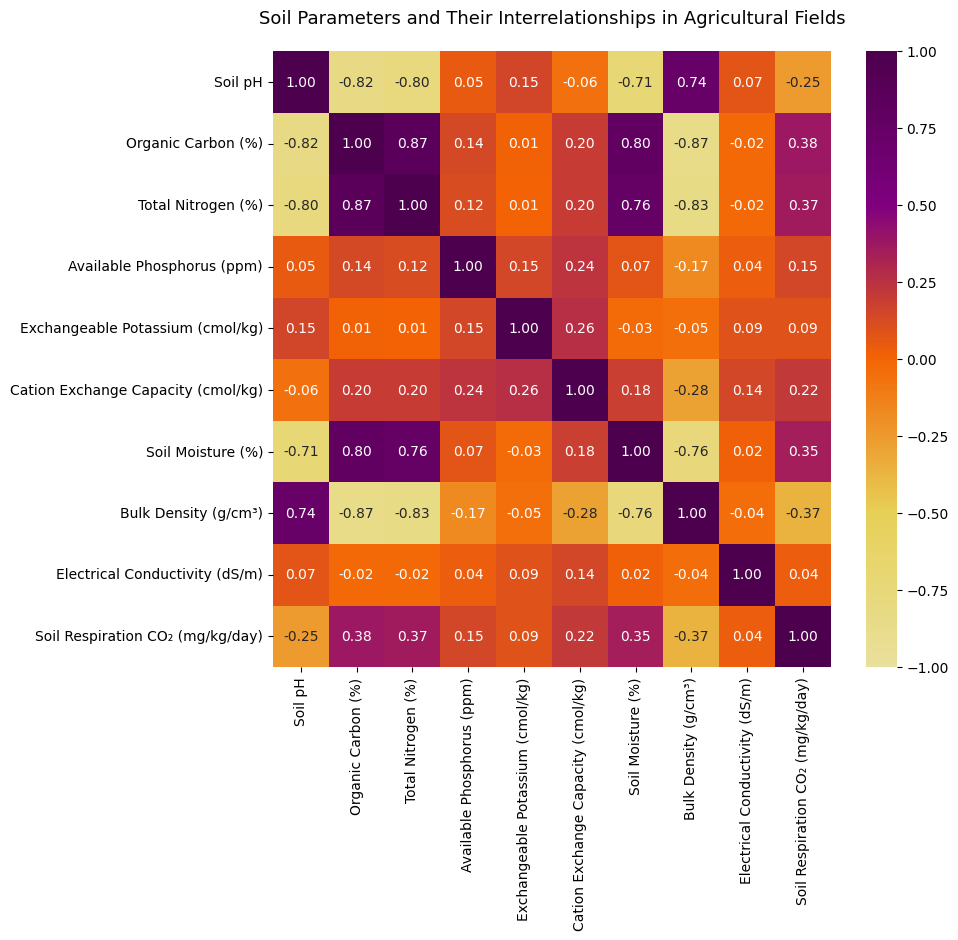

In [11]:
if __name__ == "__main__":
    plt.figure(figsize=(9, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap=cmap, fmt='.2f', vmin=-1, vmax=1)
    plt.title("Soil Parameters and Their Interrelationships in Agricultural Fields", 
              color='k',
              fontsize = 13,
              pad = 20,
              weight=500
             )
    plt.grid(False)
    plt.show()

<h3 style='font-family: Bradley Hand ITC; font-size: 20px; font-weight: 600'>5.4: CORRELATION COEFFICIENTS & STATISTICAL SIGNIFICANCE, STRENGTH AND DIRECTIONS </h3>

In [12]:
def get_pearsonr_results(df: pd.DataFrame, variables: List[str])->pd.DataFrame:
    results = []

    for i, variable1 in enumerate(variables):
        for variable2 in variables[i+1:]:
            r_value, p_value = pearsonr(df[variable1], df[variable2])
            direction = ("Positive" if r_value > 0 else "Negative" if r_value < 0 else "No correlation")
            strength = ("Strong" if abs(r_value) >= 0.7 else "Moderate" if abs(r_value) >= 0.3 else "Weak")
            
            results.append({
                'Variable 1': variable1, 
                'Variable 2': variable2,
                'Pearson\'s r': r_value, 
                'P-value': p_value,
                'Direction': direction, 
                'Strength': strength
            })
    
    return pd.DataFrame(results)

variables = df.select_dtypes(include=['number']).columns
pearson_results_df = get_pearsonr_results(df, variables=variables)
pearson_results_df

,Variable 1,Variable 2,Pearson's r,P-value,Direction,Strength
0,Soil pH,Organic Carbon (%),-0.82,0.00,Negative,Strong
1,Soil pH,Total Nitrogen (%),-0.80,0.00,Negative,Strong
2,Soil pH,Available Phosphorus (ppm),0.05,0.32,Positive,Weak
3,Soil pH,Exchangeable Potassium (cmol/kg),0.15,0.00,Positive,Weak
4,Soil pH,Cation Exchange Capacity (cmol/kg),-0.06,0.22,Negative,Weak
5,Soil pH,Soil Moisture (%),-0.71,0.00,Negative,Strong
6,Soil pH,Bulk Density (g/cm³),0.74,0.00,Positive,Strong
7,Soil pH,Electrical Conductivity (dS/m),0.07,0.14,Positive,Weak
8,Soil pH,Soil Respiration CO₂ (mg/kg/day),-0.25,0.00,Negative,Weak
9,Organic Carbon (%),Total Nitrogen (%),0.87,0.00,Positive,Strong


<h3 style='font-family: Bradley Hand ITC; font-size: 20px; font-weight: 600'>5.5: CORRELATION COEFFICIENTS CUSTOME VISUALIZATIONS</h3>

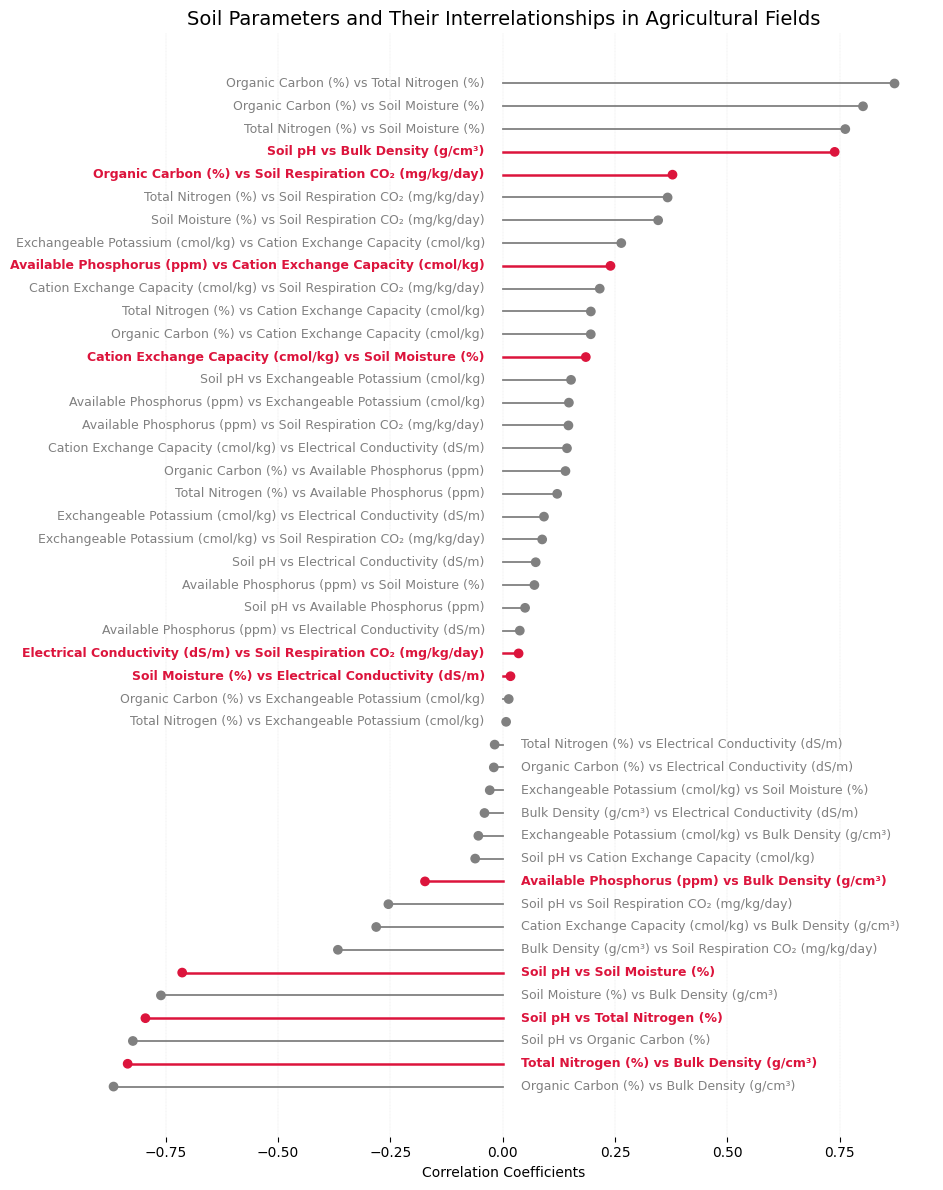

In [15]:
def compute_correlation_pairs(df, method="pearson"):
    numeric_df = df.select_dtypes(include=np.number)
    corr_matrix = numeric_df.corr(method=method)
    corr_pairs = corr_matrix.stack().reset_index()
    corr_pairs.columns = ["var1", "var2", "correlation"]
    corr_pairs = corr_pairs[corr_pairs["var1"] != corr_pairs["var2"]]
    corr_pairs["pair"] = corr_pairs["var1"] + " vs " + corr_pairs["var2"]
    corr_pairs = corr_pairs.drop_duplicates(subset=["correlation"])
    return corr_pairs.sort_values(by="correlation", ascending=False)

def sample_highlight_pairs(df, n=5): return df["pair"].sample(n=n, random_state=42).tolist()

def get_color_mappings(
    df, 
    highlights, 
    highlight_color="tab:red", 
    default_color="grey"):
    return [highlight_color if pair in highlights else default_color for pair in df["pair"]]

def plot_correlation_highlight(
    df: pd.DataFrame, 
    highlights, 
    figsize: tuple = (10, 12),
    highlight_color: str = "tab:red", 
    default_color: str = "grey", 
    segment_width: int = 1.5, 
    text_size: int = 10, 
    nudge_x: float = 0.03):
    
    
    df["highlight"] = df["pair"].isin(highlights)
    df["color"] = get_color_mappings(df, highlights, highlight_color, default_color)
    
    fig, ax = plt.subplots(figsize=figsize)
    df = df.sort_values("correlation")

    for _, row in df.iterrows():
        ax.plot([0, row["correlation"]],
                [row["pair"], row["pair"]], 
                color=row["color"], 
                linewidth=segment_width + (0.5 if row["highlight"] else 0))

    ax.scatter(df["correlation"], df["pair"], color=df["color"], zorder=3)
    
    for _, row in df.iterrows():
        align = 'right' if row["correlation"] > 0 else 'left'
        x_offset = -nudge_x if row["correlation"] > 0 else nudge_x
        ax.text(0 + x_offset, row["pair"], row["pair"],
                ha=align, 
                va='center', 
                color=row["color"],
                fontweight='bold' if row["highlight"] else 'normal',
                fontsize=text_size
                )


    ax.grid(True, linestyle='--', linewidth=0.2, color='lightgray')
    sns.despine(left=True, bottom=True)
    plt.title("Soil Parameters and Their Interrelationships in Agricultural Fields", 
              fontsize=14, 
              color='k', 
              weight=500
             )
    ax.set_xlabel("Correlation Coefficients", color='k')
    ax.set_ylabel("")
    ax.set_yticks([])
    
    plt.tight_layout()
    plt.show()


correlations = compute_correlation_pairs(df)
highlighted_pairs = sample_highlight_pairs(correlations, n=10)
plot_correlation_highlight(
    correlations,
    highlights=highlighted_pairs,
    highlight_color="crimson",
    default_color="gray",
    segment_width=1.3,
    text_size=9,
    nudge_x=0.04
)

---

This analysis was performed by **Jabulente**, a passionate and dedicated data analyst with a strong commitment to using data to drive meaningful insights and solutions. For inquiries, collaborations, or further discussions, please feel free to reach out.  

----

<h1 style='font-size: 35px; color: red; font-family: Colonna MT; font-weight: 700; text-align: center'>Data to Drive Meaningful Insights and Solutions</h1>